In [ ]:
!nvidia-smi


Thu Sep 10 19:26:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import numpy as np
import tensorflow as tf

def erroquadratico(alvo, saida):
  return np.mean((alvo - saida)**2)

def gradiente(alvo, saida):
  return 2*(alvo - saida)

def preditor(x, w, b):
  return w*x + b

def backprop(x, y_real, w, b, taxa):
  y_pred = preditor(x, w, b)
  erro = erroquadratico(y_real, y_pred)

  grad_w = -gradiente(y_real, y_pred) * x
  grad_b = -gradiente(y_real, y_pred)

  w -= taxa * np.mean(grad_w)
  b -= taxa * np.mean(grad_b)

  return w, b, erro


class printcallback(tf.keras.callbacks.Callback):
   def on_epoch_begin(self, epoch, logs=None):
      print(f"Epoch {epoch+1} iniciada")

   def on_epoch_end(self, epoch, logs=None):
      print(f"Epoch {epoch+1} concluída")

def sigmoid(x):
  return 1/(1+np.exp(-(x**2)))

Epoch 1 iniciada
Epoch 1 concluída
Epoch 2 iniciada
Epoch 2 concluída
Epoch 3 iniciada
Epoch 3 concluída
Epoch 4 iniciada
Epoch 4 concluída
Epoch 5 iniciada
Epoch 5 concluída
Epoch 6 iniciada
Epoch 6 concluída
Epoch 7 iniciada
Epoch 7 concluída
Epoch 8 iniciada
Epoch 8 concluída
Epoch 9 iniciada
Epoch 9 concluída
Epoch 10 iniciada
Epoch 10 concluída
Epoch 11 iniciada
Epoch 11 concluída
Epoch 12 iniciada
Epoch 12 concluída
Epoch 13 iniciada
Epoch 13 concluída
Epoch 14 iniciada
Epoch 14 concluída
Epoch 15 iniciada
Epoch 15 concluída
Epoch 16 iniciada
Epoch 16 concluída
Epoch 17 iniciada
Epoch 17 concluída
Epoch 18 iniciada
Epoch 18 concluída
Epoch 19 iniciada
Epoch 19 concluída
Epoch 20 iniciada
Epoch 20 concluída
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9544 - loss: 0.2325
Acurácia no conjunto de teste: 95.44%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step


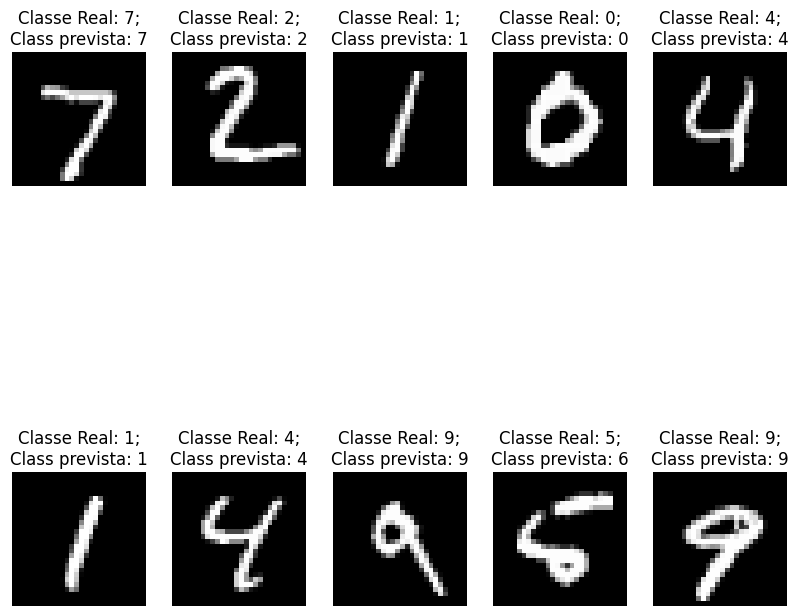

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.datasets import mnist
import google.colab as colab

callback = printcallback()


model = Sequential([
    tf.keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation="softmax"),
])

model.compile(
  optimizer="adam",
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

(x_train, y_train), (x_test, y_test) = mnist.load_data()

history = model.fit(
  x_train,
  y_train,
  epochs=20,
  batch_size=32,
  verbose=0,
  validation_split=0.2,
  callbacks=[callback]
)


model.save("mlp_mnist_model.keras")

test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Acurácia no conjunto de teste: {test_acc * 100:.2f}%")

preditor = model.predict(x_test[:10])

plt.figure(figsize=(10, 10))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Classe Real: {y_test[i]};\nClass prevista: {np.argmax(preditor[i])}")
    plt.axis('off')
plt.show()

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7614 - loss: 0.8741 - val_accuracy: 0.8242 - val_loss: 0.4912
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8284 - loss: 0.4805 - val_accuracy: 0.8196 - val_loss: 0.4777
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8449 - loss: 0.4301 - val_accuracy: 0.8541 - val_loss: 0.4066
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8540 - loss: 0.4039 - val_accuracy: 0.8549 - val_loss: 0.4416
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8619 - loss: 0.3843 - val_accuracy: 0.8587 - val_loss: 0.4033
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8683 - loss: 0.3665 - val_accuracy: 0.8633 - val_loss: 0.3884
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8723 - loss: 0.3551 - val_accuracy: 0.8697 - val_loss: 0.3733
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8746 - loss: 0.3451 

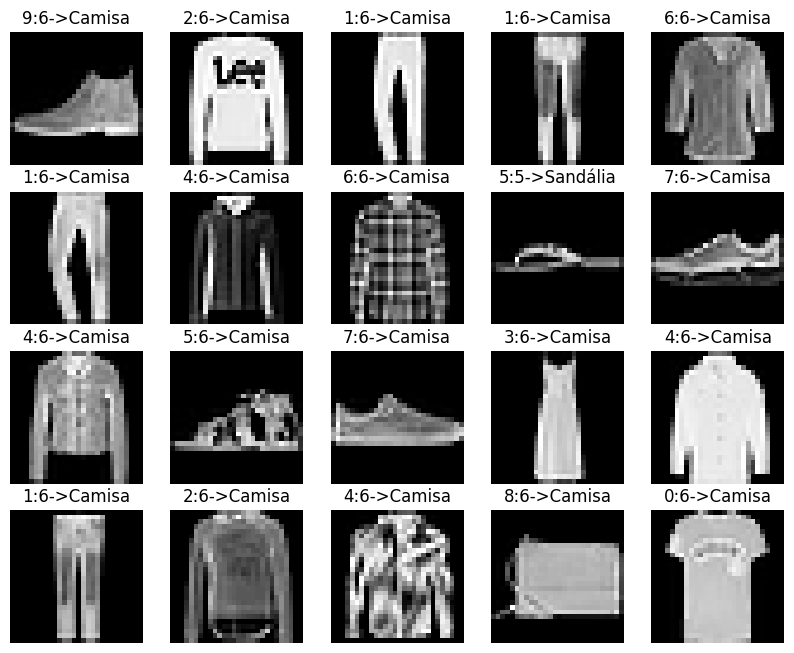

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.datasets import fashion_mnist
import google.colab as colab

tf.keras.utils.set_random_seed(42)
tf.random.set_seed(42)

callback = printcallback()

model = Sequential([
    tf.keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(256, activation='relu'),
    Dense(96, activation='relu'),
    Dense(10, activation="softmax"),
])

model.compile(
  optimizer="adam",
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

history = model.fit(
  x_train,
  y_train,
  epochs=20,
  batch_size=32,
  validation_split=0.2
)

x_train = x_train / 255.0
x_test = x_test / 255.0

CLASSES = ['Camiseta', 'Calça', 'Pulôver', 'Vestido', 'Casaco', 'Sandália',
           'Camisa', 'Tênis', 'Bolsa', 'Bota']


test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Acurácia no conjunto de teste: {test_acc * 100:.2f}%")

preditor = model.predict(x_test[:20])

plt.figure(figsize=(10, 10))
for i in range(20):
    plt.subplot(5, 5, i+1)
    plt.grid(False)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"{y_test[i]}:{np.argmax(preditor[i])}->{CLASSES[np.argmax(preditor[i])]}")
    plt.axis('off')
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Epoch 1 iniciada
Epoch 1 concluída
Epoch 2 iniciada
Epoch 2 concluída
Epoch 3 iniciada
Epoch 3 concluída
Epoch 4 iniciada
Epoch 4 concluída
Epoch 5 iniciada
Epoch 5 concluída
Epoch 6 iniciada
Epoch 6 concluída
Epoch 7 iniciada
Epoch 7 concluída
Epoch 8 iniciada
Epoch 8 concluída
Epoch 9 iniciada
Epoch 9 concluída
Epoch 10 iniciada
Epoch 10 concluída
Epoch 11 iniciada
Epoch 11 concluída
Epoch 12 iniciada
Epoch 12 concluída
Epoch 13 iniciada
Epoch 13 concluída
Epoch 14 iniciada
Epoch 14 concluída
Epoch 15 iniciada
Epoch 15 concluída
Epoch 16 iniciada
Epoch 16 concluída
Epoch 17 iniciada
Epoch 17 concluída
Epoch 18 iniciada
Epoch 18 concluída
Epoch 19 iniciada
Epoch 19 concluída
Epoch 20 iniciada
Epoch 20 concluída
Epoch 21 iniciada
Epoch 21 concluída
Epoch 22 iniciada
Epoch 22 concluída
Epoch 23 iniciada
Epoch 23 concluída
Epoch 24 iniciada
Epoch 24 concluída
Epoch 25 iniciada
Epoch 25 concluída
Epoch 26 iniciada
Epoch 26 concluída
Epoch 27 iniciada
Epoch 27 concluída
Epoch 28 iniciada
E

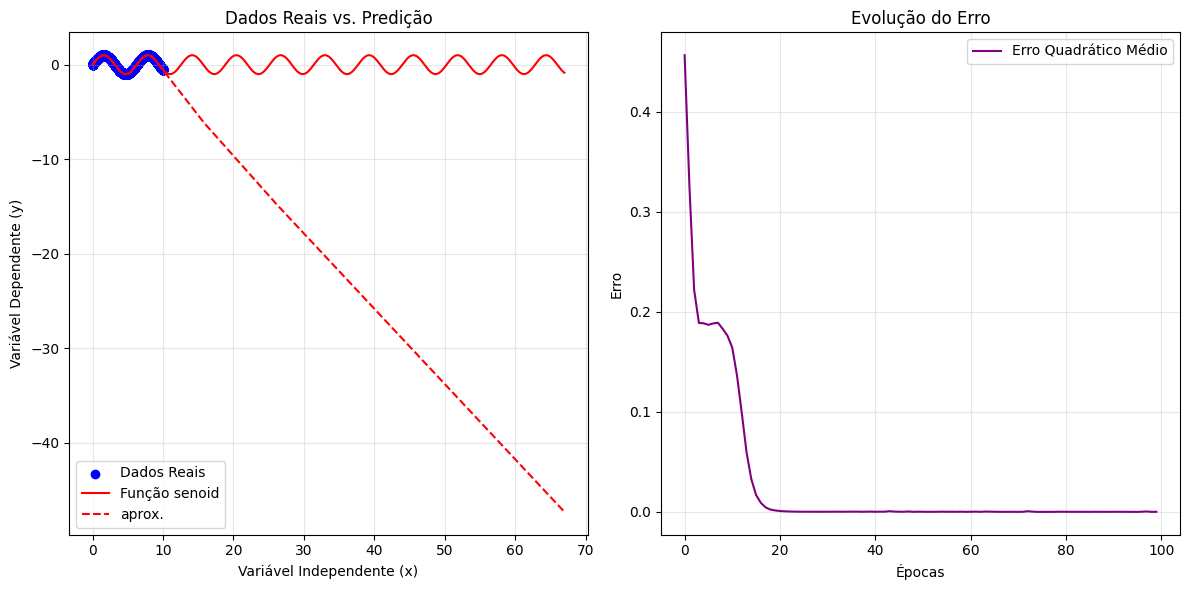

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input


callback = printcallback()


x =  np.linspace(0, 10, 6767)
y_real = np.sin(x)

w = np.random.randn(1)
b = np.random.randn(1)

model = Sequential([
    tf.keras.Input(shape=(1,)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1),
])

model.compile(
  optimizer="adam",
  loss='mean_squared_error'
)

history = model.fit(
  x,
  y_real,
  epochs=100,
  batch_size=32,
  verbose=0,
  callbacks=[callback]
)

X_range = np.linspace(0, 67, 6767)
Y_range = np.sin(X_range)
y_pred = model.predict(X_range)

weights, biases = model.layers[0].get_weights()

print(f"Peso: {weights[0][0]:.2f}")
print(f"Bias: {biases[0]:.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(x, y_real, color='blue', label='Dados Reais')
ax1.plot(X_range, Y_range, color='red', label='Função senoid')
ax1.plot(X_range, y_pred, "--", color='red', label='aprox.')
ax1.set_xlabel('Variável Independente (x)')
ax1.set_ylabel('Variável Dependente (y)')
ax1.set_title('Dados Reais vs. Predição')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], label='Erro Quadrático Médio', color='purple')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Erro')
ax2.set_title('Evolução do Erro')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

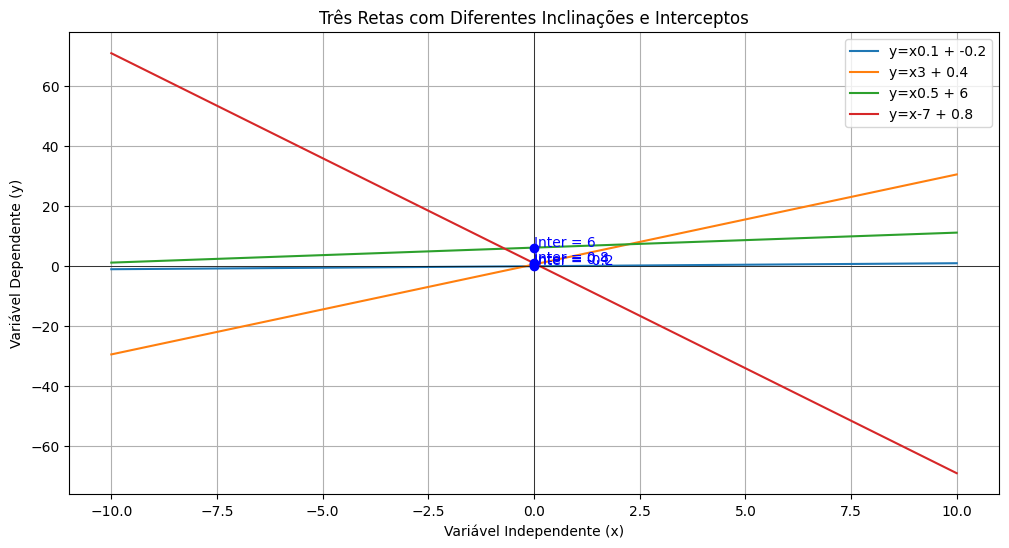

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

params = [
    {"a": 0.1, "b": -0.2},
    {"a": 3, "b": 0.4},
    {"a": 0.5, "b": 6},
    {"a": -7, "b": 0.8},
]

x = np.linspace(-10, 10, 200)

plt.figure(figsize=(12, 6))

for param in params:
    a = param["a"]
    b = param["b"]
    y = a * x + b
    plt.plot(x, y, label=f"y=x{a} + {b}")

    plt.scatter(0, b, color='blue', zorder=5)
    plt.text(0, b + 0.5, f"Inter = {b}", color="blue")

plt.title('Três Retas com Diferentes Inclinações e Interceptos')
plt.xlabel('Variável Independente (x)')
plt.ylabel('Variável Dependente (y)')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
##passos dinamicos

def pd(base, limite):
  exponte = 0

  while True:
    for mult in base:
      v = mult * (10 ** exponte)
      if v > limite:
        return
      yield v

    exponte += 1


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch


# pessos e bias randoms
def pbr(entradas: np.array, ocults: list[int], n_saidas: int):
  n_entradas = len(entradas)

  pesos = []
  bias = []

  pesos.append(np.random.randn(n_entradas, ocults[0]))
  bias.append(np.random.randn(ocults[0]))

  for i in range(1, len(ocults)):
    pesos.append(np.random.randn(ocults[i-1], ocults[i]))
    bias.append(np.random.randn(ocults[i]))

  pesos.append(np.random.randn(ocults[-1], n_saidas))
  bias.append(np.random.randn(n_saidas))

  return pesos, bias



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

w, b = -.2, np.random.randn()*1e-2
v, c = .1 , np.random.randn()*1e-2

taxa = 0.01
passos = 1000


x = np.linspace(0, np.pi/2, 21)
n = x.size
x_all = np.linspace(-np.pi, np.pi, 21)
alvo = np.cos(x)
alvo_all = np.sin(x_all)

curvas = {}

for passo in range(passos):

  z = w*x + b
  h = sigmoid(z)
  y= v*h + c

  erro = alvo - y
  L = erro**2

  dL = 2*erro/n
  dc= float(dL @ h)
  dv = float(dL.sum())
  dz = (v*dL*(1 - h**2))
  dw = float(dz @ x)
  db = float(dz.sum())


  if passo in pd([1, 5], passos):
    print(f"passo {passo}: \n\t perda {L.mean():.2f} \n\t erro maximo {np.abs(erro).max():.2f} \n\t gradiente {dL.mean():.2f}")
    curvas[passo] = y.copy()

  if passos == passo: break

  w -= taxa*dw
  b -= taxa*db
  v -= taxa*dv
  c -= taxa*dc

print(f"\nw = {w:.4f}   b = {b:.4f}   v = {v:.4f}   c = {c:.4f}")

size = 6
aspect = (9/12)
fig, ax = plt.subplots(figsize=(size, size*aspect))
ax.plot(x, alvo, lw=2.2, label="o alvo: cos(x)")
for passo, curva in curvas.items():
    ax.plot(x, curva, lw=1, label=f"saida {passo}")

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

#ax.plot(x, y, ".", lw=2.2, label="o que o neuronio devolve")
#ax.plot(x, erro, ".", lw=2.2, label="erro")
#ax.plot(x, L, ".", lw=2.2, label="distancia quadrada")
#ax.plot(x, dL, "-", lw=2.2, label="gradiente")
ax.legend(by_label.values(), by_label.keys(), frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


NameError: name 'pd' is not defined

In [ ]:
import numpy, pandas, matplotlib, sklearn, cv2
print("numpy       ", numpy.__version__)
print("pandas      ", pandas.__version__)
print("matplotlib  ", matplotlib.__version__)
print("scikit-learn", sklearn.__version__)
print("opencv      ", cv2.__version__)

numpy        2.1.3
pandas       2.2.3
matplotlib   3.10.0
scikit-learn 1.6.1
opencv       5.0.0


In [ ]:
import numpy as np

sigmoid = lambda t: 1/(1+np.exp(-t))

#create_and_calc_random_neuro
def ccrn(entreada,n_entradas, n_saidas):
  pesos = np.random.randn(n_entradas, n_saidas)
  bias = np.random.randn(n_saidas)
  return sigmoid(entreada @ pesos + bias)


def crnn(entradas):
  n_layers = len(entradas)
  neuro = []
  neuro.append(ccrn(canetas, 4, n_layers))
  for i in range(n_layers): neuro.append(ccrn(neuro[i],n_layers, n_layers))
  return ccrn(neuro[n_layers],n_layers,1)


In [ ]:
import numpy as np

eh_caneta = [
    1, # altura
    0.001, # largura
    0.001, # comprimento
    1, # risca? 0 - não, 1 - sim
]


canetas = np.array(eh_caneta)



n_layers = 100;

saida = crnn(canetas)


print(saida)
if saida > 0.5:
    print("é caneta")
else:
    print("não é caneta")

[0.68276518]
é caneta
